In [17]:
import numpy as np
import yaml
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
result_dir = "test_collection"

In [14]:
result_list = []
trials = []
for file in os.listdir(result_dir):
    if file.startswith("trial"):
        with open(os.path.join(result_dir,file),"r") as result_file:
            trials.append(file.split("_")[1])
            results = yaml.safe_load(result_file)
            result_list.append(results)
result_df = pd.DataFrame(result_list) 
result_df.index = trials


In [15]:
print(result_df)

    distance_traveled
23          49.098919
28          49.167461
29          49.144614
30          49.236003
31          49.121767
32          49.144614
33          49.030377
35          49.373087


In [16]:
total_trials = len(result_df)
total_distance = result_df.distance_traveled.sum()

In [ ]:
summary_df = result_df.group_by("nav_type")

In [3]:
summary_df = pd.DataFrame([{"nav":"Distance","env":"Base","trials":"Placeholder","dist":"Placeholder","avg_obs":"Placeholder","acc_rate":"Placeholder"},
                           {"nav":"Distance","env":"Train","trials":"Placeholder","dist":"Placeholder","avg_obs":"Placeholder","acc_rate":"Placeholder"}])

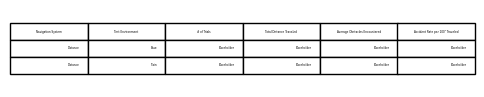

In [9]:
fig, ax = plt.subplots(figsize=(6, 1)) 
ax.axis('off')
ax.table(cellText=summary_df.values, colLabels=["Navigation System","Test Environment", "# of Trials","Total Distance Traveled","Average Obstacles Encountered","Accident Rate per 100\" Traveled"], loc='center')

plt.savefig("result_table.png", dpi=300)

In [ ]:
plt.clf()

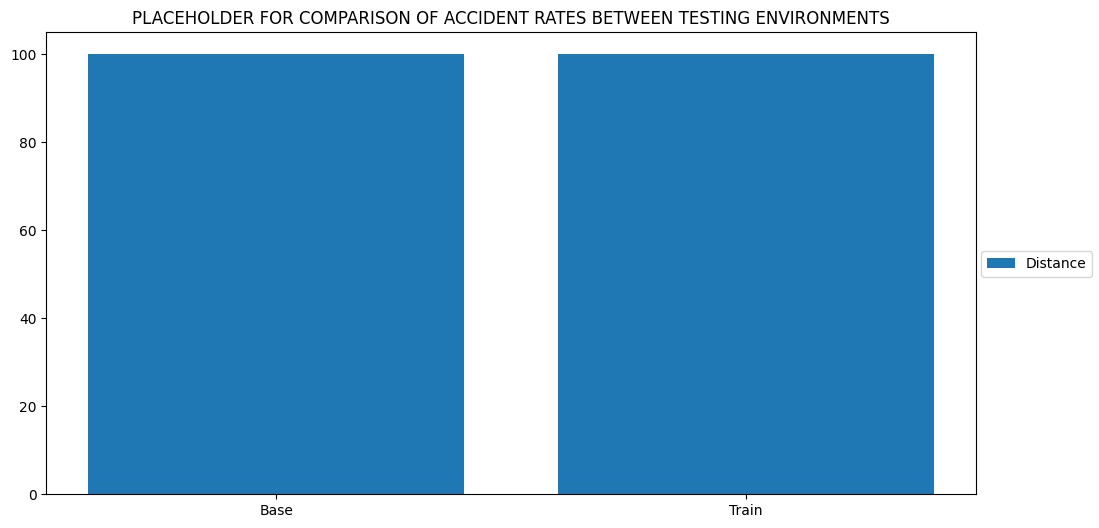

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.bar(summary_df.env,[100,100],label=summary_df.nav)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),loc='outside right center')

ax.set_title("PLACEHOLDER FOR COMPARISON OF ACCIDENT RATES BETWEEN TESTING ENVIRONMENTS")
#fig.legend()
plt.savefig("result_bar.png", dpi=300)